IDEA: COLOR DETECTION DEL LED
1. CROP: Invece di analizzare l'intera foto, l'algoritmo isola l'area di interesse convertendo l'immagine nello spazio colore HSV. Viene estratto il canale Value e, tramite una sfocatura gaussiana per ridurre il rumore, viene identificato il punto di massima intensità luminosa (=cuore del LED). Attorno a questo punto viene creato un ritaglio (crop) di sicurezza (es. 80x80 pixel).

2. COLOR EXTRACTION: Sul ritaglio ottenuto, il codice applica un filtro di Saturazione. Questo passaggio è fondamentale perché il cuore del LED spesso appare bianco (clipping); filtrando i pixel poco saturi, l'algoritmo si concentra sull'alone colorato circostante. I pixel rimanenti vengono confrontati con dei range predefiniti di Hue (Tinta) per i colori target (Rosso, Verde, Blu, Giallo, Viola).

3. WINNER DETECTION & CONFIDENCE COMPUTATION: Il sistema assegna il colore basandosi sulla maggioranza dei pixel rilevati e calcola uno score di confidence (la percentuale di pixel che appartiene a quel colore rispetto al totale). 

OPZIONALE: output visivo che sovrappone un rettangolo di tracciamento e l'etichetta del colore sull'immagine originale.

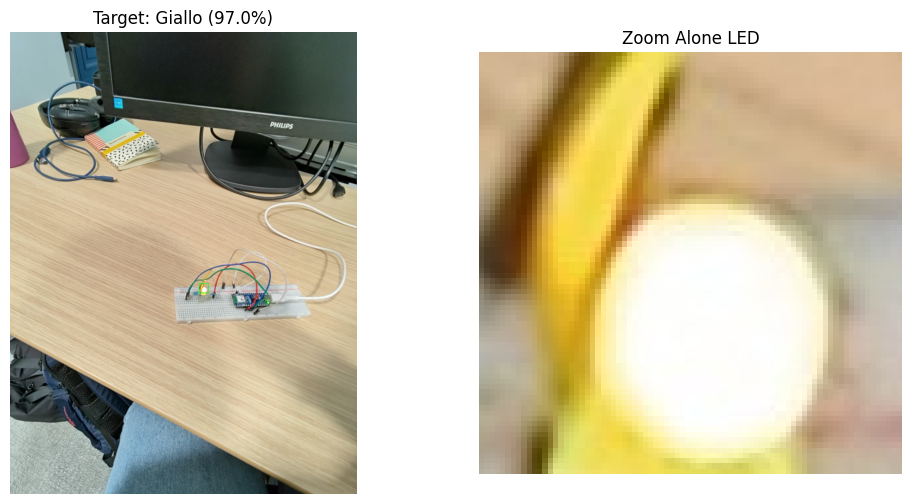

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def analyze_led_circuit(image_path):
    img = cv2.imread(image_path)
    if img is None:
        print(f"Errore: Impossibile caricare {image_path}")
        return
    
    # Conversione in HSV per isolare la luminosità (Value)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    v_channel = hsv[:, :, 2]
    
    # Sfocatura per eliminare picchi di rumore puntiformi
    blurred_v = cv2.GaussianBlur(v_channel, (15, 15), 0)
    
    # Cerchiamo il punto più luminoso 
    _, max_val, _, max_loc = cv2.minMaxLoc(blurred_v)
    x, y = max_loc
    
    # Controllo qualità: se il punto più luminoso è troppo scuro, il LED è spento
    if max_val < 150:
        print("LED non rilevato o troppo spento.")
        return "Spento", 0.0

    # Definiamo l'area di ritaglio (80x80 pixel circa)
    padding = 40
    h, w = img.shape[:2]
    x1, y1 = max(0, x - padding), max(0, y - padding)
    x2, y2 = min(w, x + padding), min(h, y + padding)
    led_crop = img[y1:y2, x1:x2]
    hsv_crop = hsv[y1:y2, x1:x2]


    # Creiamo una maschera per escludere il centro bianco (Sat < 60) e pixel scuri
    color_mask = cv2.inRange(hsv_crop, (0, 60, 60), (180, 255, 255))
    valid_pixels = hsv_crop[color_mask > 0]

    if len(valid_pixels) == 0:
        return "Indeterminato", 0.0

    # Range Hue 
    color_ranges = {
        "Rosso": [(0, 10), (165, 180)],
        "Giallo": [(15, 35)],
        "Verde": [(45, 85)],
        "Blu": [(100, 130)],
        "Viola": [(135, 160)]
    }

    hues = valid_pixels[:, 0]
    votes = {}
    for color, ranges in color_ranges.items():
        count = sum(np.sum((hues >= low) & (hues <= high)) for low, high in ranges)
        votes[color] = count

    # Color e Confidence
    winner = max(votes, key=votes.get)
    confidence = votes[winner] / len(valid_pixels)

    # --- 4. PLOT DEI RISULTATI ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    
    # Immagine originale con rettangolo e testo
    img_res = cv2.cvtColor(img.copy(), cv2.COLOR_BGR2RGB)
    cv2.rectangle(img_res, (x1, y1), (x2, y2), (0, 255, 0), 3)
    ax1.imshow(img_res)
    ax1.set_title(f"Target: {winner} ({confidence:.1%})")
    ax1.axis('off')

    # Zoom sul LED
    crop_res = cv2.cvtColor(led_crop, cv2.COLOR_BGR2RGB)
    ax2.imshow(crop_res)
    ax2.set_title("Zoom Alone LED")
    ax2.axis('off')

    plt.show()
    
    return winner, confidence


result = analyze_led_circuit('color_detection/giallo_step1Completato.jpg')